In [1]:
!pip install yfinance tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.7/372.7 kB 4.8 MB/s eta 0:00:00


Loading 'Trace' dataset...
Data Shape: (50, 275, 1) (Samples x Timesteps x Dimensions)


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

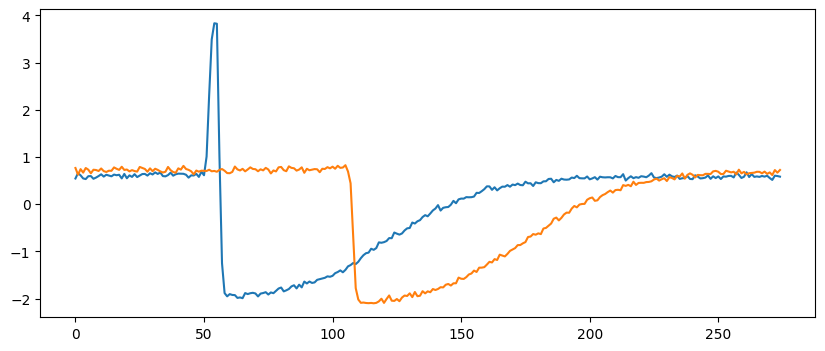

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans

# 1. Load the "Trace" dataset
# This is a standard dataset used in Time Series papers (PapersWithCode)
print("Loading 'Trace' dataset...")
X_train, y_train, X_test, y_test = UCR_UEA_datasets().load_dataset('Trace')

# We will only use the first 50 samples to make the plot readable
X = X_train[:50]
y = y_train[:50]

print(f"Data Shape: {X.shape} (Samples x Timesteps x Dimensions)")

# 2. Preprocessing
# Scale the time series to have mean 0 and variance 1
# This ensures the clustering focuses on the SHAPE, not the amplitude
X_scaled = TimeSeriesScalerMeanVariance().fit_transform(X)

# Visualize a few raw samples
plt.figure(figsize=(10, 4))
plt.plot(X_scaled[0].ravel(), label="Sample 1")
plt.plot(X_scaled[1].ravel(), label="Sample 2")
plt

In [4]:
# 3. Define the Model
# We use 'softdtw' which is a state-of-the-art metric for time series averaging
# We set n_clusters=4 because the Trace dataset is known to have 4 classes
n_clusters = 4
model = TimeSeriesKMeans(n_clusters=n_clusters,
                         metric="softdtw",
                         max_iter=20,
                         random_state=42)

print("Training TimeSeriesKMeans with Soft-DTW...")
y_pred = model.fit_predict(X_scaled)
print("Training Complete.")

Training TimeSeriesKMeans with Soft-DTW...
Training Complete.


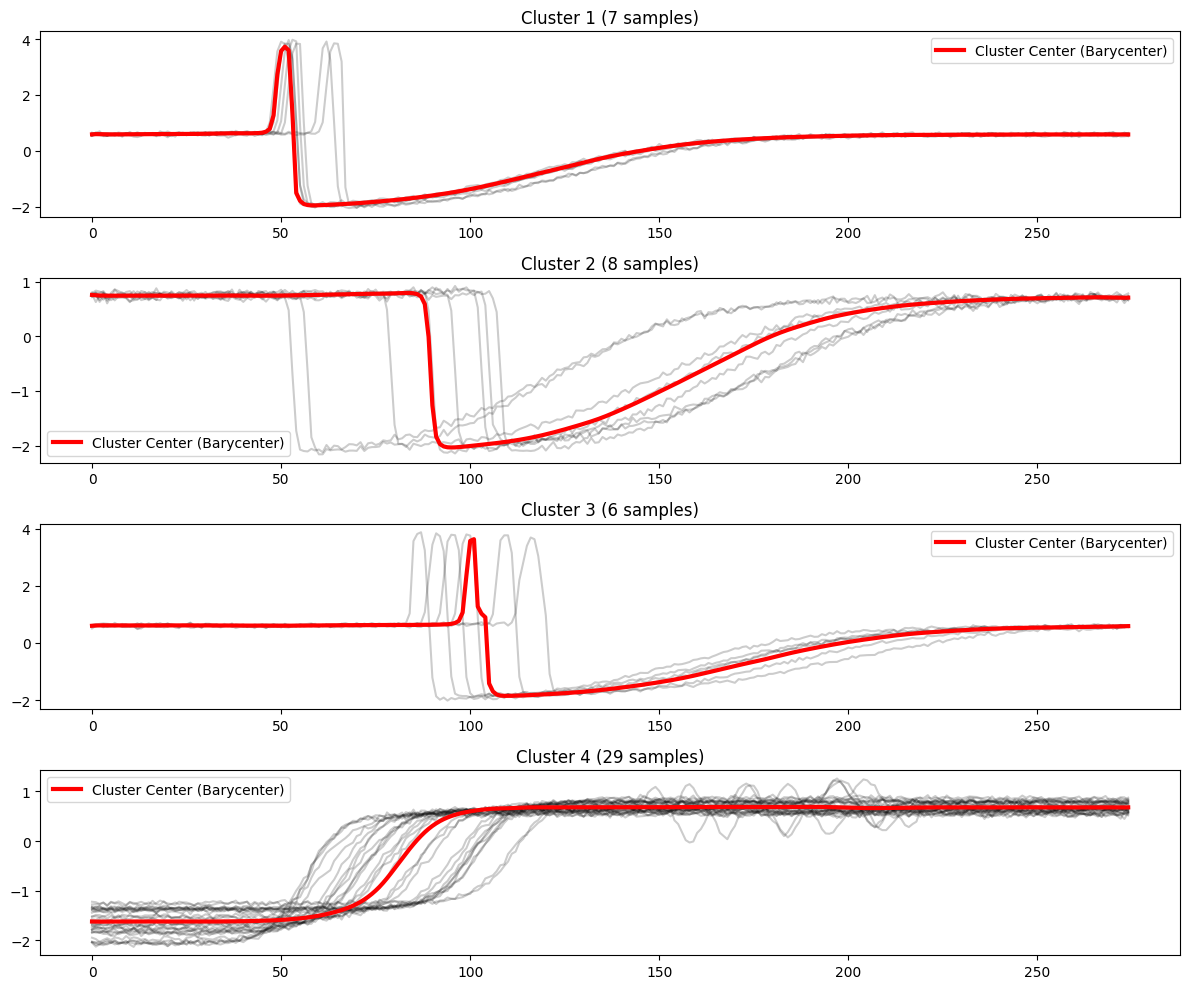

In [5]:
# 4. Visualize the Clusters and their "Barycenters"
plt.figure(figsize=(12, 10))

for cluster_id in range(n_clusters):
    plt.subplot(n_clusters, 1, cluster_id + 1)

    # Select all data points assigned to this cluster
    cluster_indices = np.where(y_pred == cluster_id)[0]

    # Plot the individual time series (thin gray lines)
    for idx in cluster_indices:
        plt.plot(X_scaled[idx].ravel(), "k-", alpha=0.2)

    # Plot the learned cluster center (The Barycenter) in Red
    plt.plot(model.cluster_centers_[cluster_id].ravel(), "r-", linewidth=3, label="Cluster Center (Barycenter)")

    plt.title(f"Cluster {cluster_id + 1} ({len(cluster_indices)} samples)")
    plt.legend()

plt.tight_layout()
plt.show()